In [1]:
import os
import pandas as pd
from features import *
import matplotlib.pyplot as plt

In [98]:
def complete_dict(list_dataframe, clean):
    if clean:
        path = "../Data/train/with_label/clean"
    else:
        path = "../Data/train/with_label/dirty"
    for e in os.scandir(path):
        if e.is_file():
            dict = {}
            path = e.path
            dict['name'] = e.name
            features_img = extract_features(path)
            for key in features_img.keys():
                dict[key] = features_img[key]
            if clean:
                dict['class'] = 'clean'
            else:
                dict['class'] = 'dirty'
            list_dataframe.append(dict)

In [99]:
def get_dataframe() -> list:
    list_dataframe = []

    complete_dict(list_dataframe, 1)
    complete_dict(list_dataframe, 0)

    return list_dataframe

In [100]:
list_df = get_dataframe()
df = pd.DataFrame(list_df)


In [101]:
df

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste,saturation,hist_rgb,hist_luminance,edge_density,class
0,train_clean_img_001.jpeg,69.07,600,600,122.39,127.30,121.97,125.22429,255,29.08,"{""red"": [110, 28, 27, 20, 38, 36, 58, 58, 73, ...","[1, 33, 27, 15, 22, 21, 28, 35, 37, 45, 41, 61...",0.1123,clean
1,train_clean_img_002.jpeg,35.45,600,529,106.65,114.13,105.04,110.85722,254,35.08,"{""red"": [8, 3, 1, 5, 2, 7, 12, 31, 34, 36, 61,...","[0, 1, 3, 1, 9, 4, 13, 18, 31, 56, 82, 84, 82,...",0.0545,clean
2,train_clean_img_003.jpeg,57.77,600,688,122.54,121.58,120.12,121.70060,255,44.79,"{""red"": [52, 27, 31, 31, 43, 41, 58, 51, 60, 5...","[3, 13, 10, 18, 36, 33, 41, 48, 59, 75, 61, 67...",0.0541,clean
3,train_clean_img_004.jpeg,47.19,600,600,130.69,132.25,129.66,131.48830,254,17.20,"{""red"": [8, 1, 3, 7, 12, 6, 14, 12, 23, 23, 25...","[0, 4, 2, 4, 2, 3, 9, 13, 15, 20, 22, 30, 41, ...",0.0677,clean
4,train_clean_img_005.jpeg,192.64,1382,1496,111.27,109.90,101.31,109.33037,255,40.16,"{""red"": [65, 40, 38, 86, 154, 289, 469, 834, 1...","[11, 44, 69, 108, 240, 408, 844, 1573, 2059, 2...",0.0330,clean
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,train_no_label_img_042.jpeg,69.44,600,627,124.36,114.45,94.19,115.10345,254,63.58,"{""red"": [1, 1, 0, 2, 1, 1, 2, 2, 0, 2, 4, 1, 7...","[0, 2, 1, 0, 1, 0, 6, 6, 4, 4, 10, 14, 12, 20,...",0.1001,dirty
92,train_no_label_img_043.jpeg,43.37,600,427,119.47,118.59,112.83,118.19648,255,25.41,"{""red"": [77, 31, 24, 29, 39, 61, 55, 81, 118, ...","[16, 62, 43, 34, 51, 76, 83, 102, 100, 106, 89...",0.0891,dirty
93,train_no_label_img_044.jpeg,58.30,600,569,121.13,111.90,108.10,114.22657,255,32.27,"{""red"": [7, 4, 1, 6, 6, 2, 7, 6, 5, 8, 7, 8, 1...","[1, 10, 9, 4, 7, 7, 12, 5, 7, 13, 15, 14, 21, ...",0.0846,dirty
94,train_no_label_img_046.jpeg,2608.48,2448,3264,140.68,130.64,124.87,132.98418,245,46.00,"{""red"": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 2, 2, 6, ...",0.0441,dirty


In [102]:
df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density']] = df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density']].astype(float)

df[['image_width', 'image_height', 'contraste']] = df[['image_width', 'image_height', 'contraste']].astype(int)

In [103]:
df[df['class'] == 'clean'].describe()

,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste,saturation,edge_density
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,93.021321,678.905660,686.169811,117.993585,116.384528,110.436792,116.187594,252.037736,45.191887,0.078275
std,243.339981,477.202193,368.418122,17.393515,17.807941,20.092193,17.681937,6.762346,20.688020,0.035783
min,16.980000,600.000000,323.000000,61.390000,48.540000,31.350000,50.422490,218.000000,10.430000,0.014900
25%,47.840000,600.000000,555.000000,112.640000,109.900000,101.310000,110.791780,253.000000,34.060000,0.054100
50%,60.290000,600.000000,600.000000,118.430000,117.210000,111.580000,117.102790,255.000000,42.240000,0.069300
75%,69.070000,600.000000,696.000000,129.120000,126.690000,120.120000,125.224290,255.000000,53.530000,0.107800
max,1821.850000,4000.000000,3000.000000,152.590000,153.290000,155.560000,152.468600,255.000000,154.920000,0.167000


In [104]:
df[df['class'] == 'dirty'].describe()


,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste,saturation,edge_density
count,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
mean,496.491628,935.418605,920.325581,117.010465,112.871163,104.958837,113.206809,250.325581,51.836279,0.075872
std,1196.416481,843.024720,802.036536,16.189217,18.222748,22.917660,17.329750,8.308690,29.494164,0.036072
min,20.950000,187.000000,141.000000,66.520000,65.340000,39.770000,68.244080,223.000000,20.280000,0.016000
25%,32.355000,600.000000,450.000000,106.895000,105.555000,95.750000,104.776115,250.500000,34.460000,0.046450
50%,58.300000,600.000000,641.000000,119.470000,116.900000,111.210000,115.891970,254.000000,44.720000,0.082400
75%,130.180000,600.000000,801.500000,126.245000,124.110000,119.240000,124.471750,255.000000,55.655000,0.097950
max,6458.140000,4032.000000,3264.000000,150.610000,143.450000,140.300000,142.702880,255.000000,155.390000,0.146100


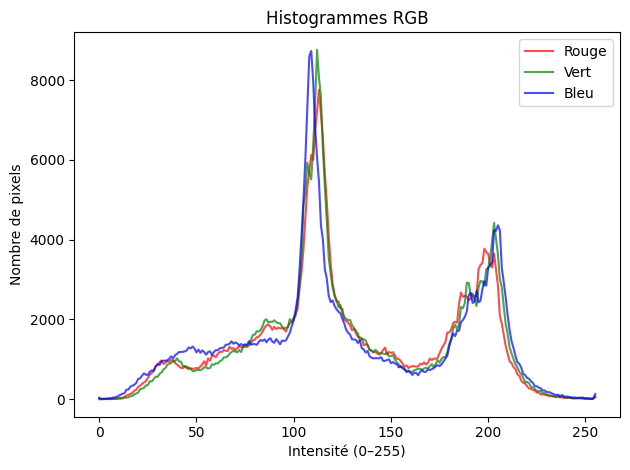

In [105]:
hist_string = df[df['class'] == "dirty"].head(1)["hist_rgb"]
hist = json.loads(hist_string.values[0])

plt.plot(hist["red"],   label="Rouge", color="red",   alpha=0.7)
plt.plot(hist["green"], label="Vert",  color="green", alpha=0.7)
plt.plot(hist["blue"],  label="Bleu",  color="blue",  alpha=0.7)


plt.xlabel("Intensité (0–255)")
plt.ylabel("Nombre de pixels")
plt.title("Histogrammes RGB")
plt.legend()
plt.tight_layout()
plt.show()

plt.show()

In [106]:
df_clean = df[df['class'] == 'clean']
df_dirty = df[df['class'] == 'dirty']

In [107]:
df_dirty = df_dirty.reset_index()

Plot width for each images

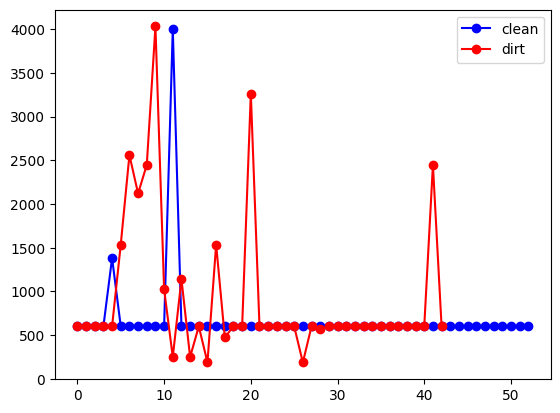

In [108]:
plt.plot(df_clean.index, df_clean['image_width'], '-o', c='blue', label="clean")
plt.plot(df_dirty.index, df_dirty['image_width'], '-o', c='red', label="dirt")
plt.legend()
plt.show()

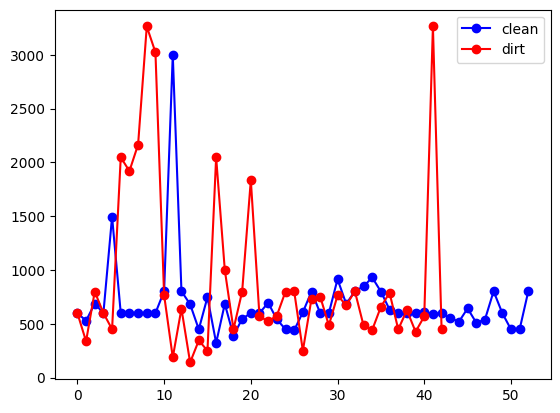

In [109]:
plt.plot(df_clean.index, df_clean['image_height'], '-o', c='blue', label="clean")
plt.plot(df_dirty.index, df_dirty['image_height'], '-o', c='red', label="dirt")
plt.legend()
plt.show()

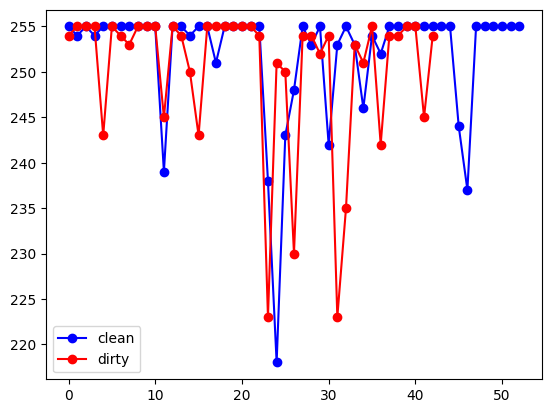

In [110]:
plt.plot(df_clean.index, df_clean['contraste'], '-o', c='blue', label="clean")
plt.plot(df_dirty.index, df_dirty['contraste'], '-o', c='red', label="dirty")
plt.legend()
plt.show()


Dans ton coinggg

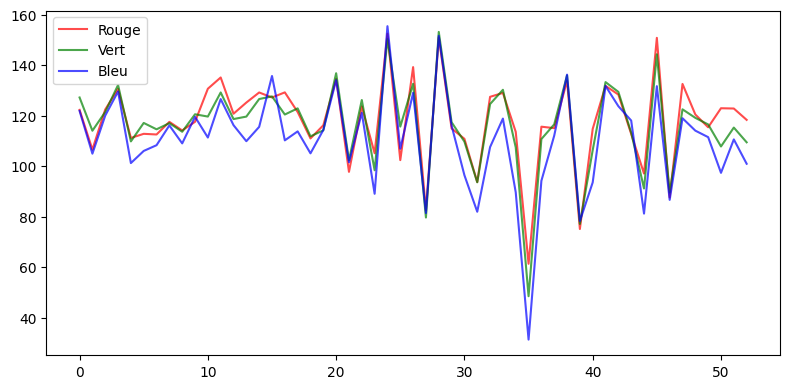

In [111]:

r_values = df_clean["mean_r"]
g_values = df_clean["mean_g"]
b_values = df_clean["mean_b"]
plt.figure(figsize=(8, 4))
plt.plot(r_values,   label="Rouge", color="red",   alpha=0.7)
plt.plot(g_values, label="Vert",  color="green", alpha=0.7)
plt.plot(b_values,  label="Bleu",  color="blue",  alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

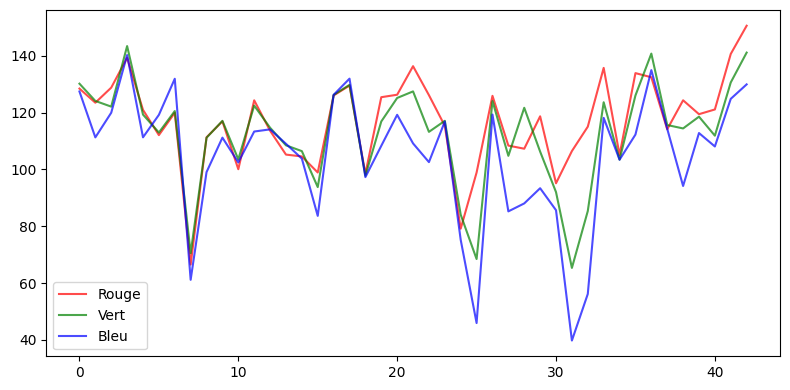

In [112]:
r_values = df_dirty["mean_r"]
g_values = df_dirty["mean_g"]
b_values = df_dirty["mean_b"]
plt.figure(figsize=(8, 4))
plt.plot(r_values,   label="Rouge", color="red",   alpha=0.7)
plt.plot(g_values, label="Vert",  color="green", alpha=0.7)
plt.plot(b_values,  label="Bleu",  color="blue",  alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()